# Fundamentals

# Data Acquisition
Immporting dataset from different Sources 

Load CSV file

In [2]:
import pandas as pd


df=pd.read_csv('customer_churn_data.csv')
df.head()

,CustomerID,Age,Income,Purchases,Gender,Churn
0,CUST_0001,56.0,24300.0,5.0,Female,0
1,CUST_0002,NaN,54000.0,11.0,Male,0
2,CUST_0003,46.0,61900.0,17.0,Male,0
3,CUST_0004,32.0,54400.0,9.0,Female,1
4,CUST_0005,60.0,20000.0,9.0,Male,1


json file 

In [3]:
df1=pd.read_json(r'C:\Users\Lenovo\Desktop\Data PP & FE\Data Profiler PR1\customer_churn_data.json')
df1.head()

,CustomerID,Age,Income,Purchases,Gender,Churn
0,CUST_0001,42.0,62000,14.0,Female,0
1,CUST_0002,28.0,34000,3.0,Male,1
2,CUST_0003,NaN,48000,8.0,Female,0
3,CUST_0004,56.0,75000,NaN,Male,1
4,CUST_0005,33.0,91000,19.0,Female,0


SQL file

API file


In [4]:
import requests
response=requests.get('https://products-u9g7r5h5qn.mock.tool.postman.dev/products')
df=pd.DataFrame(response.json()['data'])
df.sample(5)

,Age,Churn,City,CustomerID,Gender,Income,Purchases,SupportCalls,TenureMonths,TotalSpent,Visits,id
46,31,No,Surat,1047,Male,47000,9,2,21,27000,14,47
5,24,No,Surat,1006,Female,33000,10,1,22,28000,15,6
30,42,Yes,Mumbai,1031,Male,70000,4,5,10,12000,6,31
36,30,No,Surat,1037,Male,45000,8,2,18,24000,12,37
7,29,No,Ahmedabad,1008,Female,44000,9,2,20,27000,13,8


# Data Understanding & Cleaning 

perform initial exploration

In [5]:
df.head()


,Age,Churn,City,CustomerID,Gender,Income,Purchases,SupportCalls,TenureMonths,TotalSpent,Visits,id
0,25,No,Surat,1001,Male,35000,8,2,18,24000,12,1
1,42,Yes,Mumbai,1002,Female,52000,3,7,8,9000,5,2
2,31,No,Ahmedabad,1003,Male,41000,12,1,30,36000,20,3
3,28,No,Pune,1004,Female,48000,6,3,14,18000,10,4
4,37,Yes,Delhi,1005,Male,62000,2,8,6,7000,4,5


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Age           50 non-null     int64 
 1   Churn         50 non-null     object
 2   City          50 non-null     object
 3   CustomerID    50 non-null     int64 
 4   Gender        50 non-null     object
 5   Income        50 non-null     int64 
 6   Purchases     50 non-null     int64 
 7   SupportCalls  50 non-null     int64 
 8   TenureMonths  50 non-null     int64 
 9   TotalSpent    50 non-null     int64 
 10  Visits        50 non-null     int64 
 11  id            50 non-null     int64 
dtypes: int64(9), object(3)
memory usage: 4.8+ KB


In [7]:
df.describe()

,Age,CustomerID,Income,Purchases,SupportCalls,TenureMonths,TotalSpent,Visits,id
count,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.00000
mean,33.160000,1025.50000,51620.000000,6.880000,3.700000,16.780000,20560.000000,11.120000,25.50000
std,6.532056,14.57738,13125.594253,3.847289,2.734884,9.300625,11479.635918,6.251987,14.57738
min,22.000000,1001.00000,30000.000000,2.000000,0.000000,5.000000,6000.000000,3.000000,1.00000
25%,28.000000,1013.25000,41000.000000,3.250000,1.000000,8.250000,9500.000000,5.250000,13.25000
50%,33.500000,1025.50000,51000.000000,6.000000,3.000000,14.500000,18000.000000,10.000000,25.50000
75%,38.000000,1037.75000,61750.000000,10.000000,6.000000,24.750000,30000.000000,16.750000,37.75000
max,45.000000,1050.00000,75000.000000,14.000000,9.000000,36.000000,42000.000000,24.000000,50.00000


Apply data cleaning

In [8]:
import numpy as np
df=pd.read_csv('customer_churn_data.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  500 non-null    object 
 1   Age         485 non-null    float64
 2   Income      500 non-null    float64
 3   Purchases   490 non-null    float64
 4   Gender      500 non-null    object 
 5   Churn       500 non-null    int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 23.6+ KB


Handle missing values

In [9]:
df.isnull().sum()

CustomerID     0
Age           15
Income         0
Purchases     10
Gender         0
Churn          0
dtype: int64

In [10]:
df["Age"].fillna(df["Age"].mean(),inplace=True)
df["Purchases"].fillna(df["Purchases"].mean(),inplace=True)


In [11]:
df.isnull().sum()

CustomerID    0
Age           0
Income        0
Purchases     0
Gender        0
Churn         0
dtype: int64

In [12]:
df.dtypes

CustomerID     object
Age           float64
Income        float64
Purchases     float64
Gender         object
Churn           int64
dtype: object

All datatype are correct

Drop irrelevant column

In [13]:
df.columns

Index(['CustomerID', 'Age', 'Income', 'Purchases', 'Gender', 'Churn'], dtype='object')

# Exploratory Data Analysis(EDA)

Perform Univariate Analysis



In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Age', ylabel='Count'>

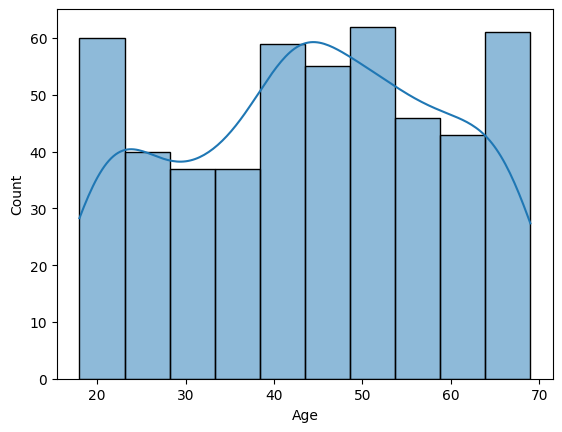

In [15]:
sns.histplot(df['Age'], kde=True)



<Axes: ylabel='Income'>

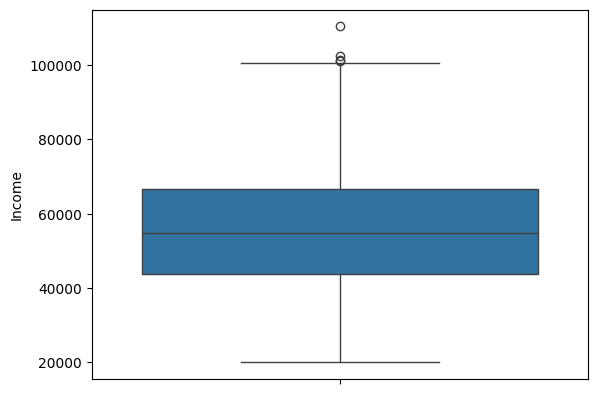

In [16]:
sns.boxplot(df['Income'])

<Axes: xlabel='Purchases', ylabel='Count'>

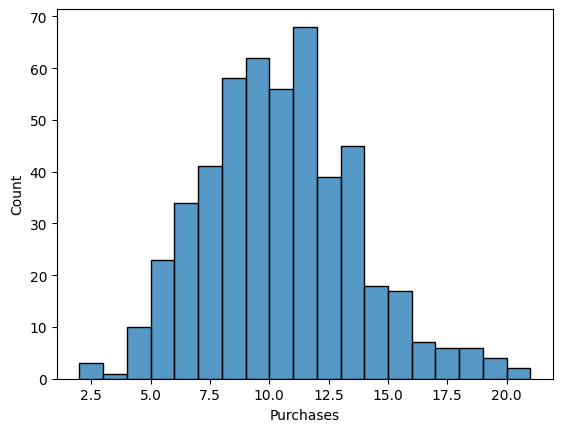

In [17]:
sns.histplot(df['Purchases'])

Perform Bivariate Analysis

<Axes: xlabel='Gender', ylabel='Purchases'>

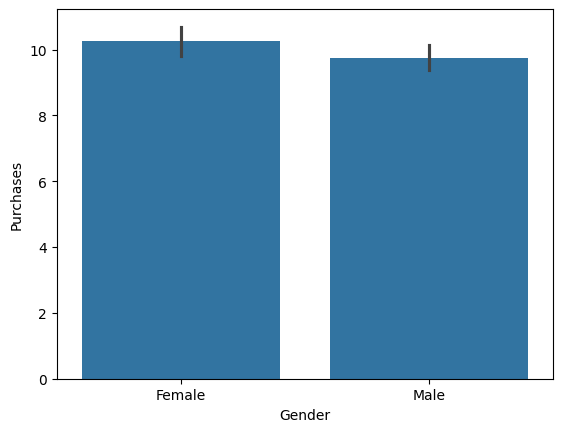

In [18]:
sns.barplot(data=df,x=df['Gender'],y=df['Purchases'])

<Axes: xlabel='Income', ylabel='Churn'>

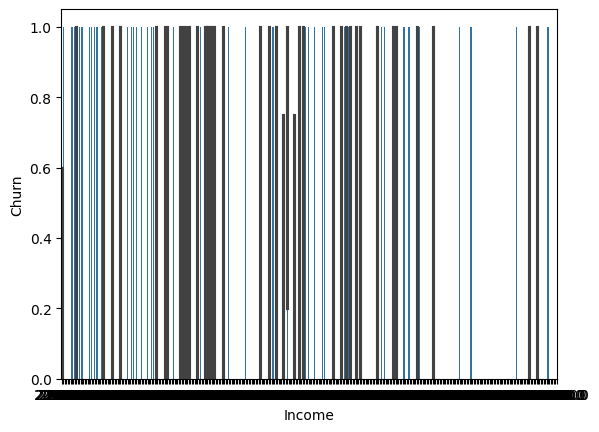

In [19]:
sns.barplot(data=df,x=df['Income'],y=df['Churn'])

Perform Multivariate Analysis

Correlation heatmap of all numerical variables

<Axes: xlabel='Age', ylabel='Income'>

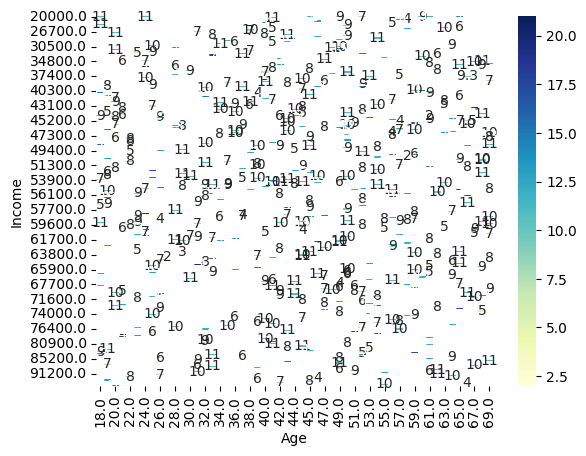

In [20]:
pivot = df.pivot_table(values="Purchases", index="Income", columns="Age", aggfunc="mean")
sns.heatmap(pivot, annot=True, cmap="YlGnBu")
 
 

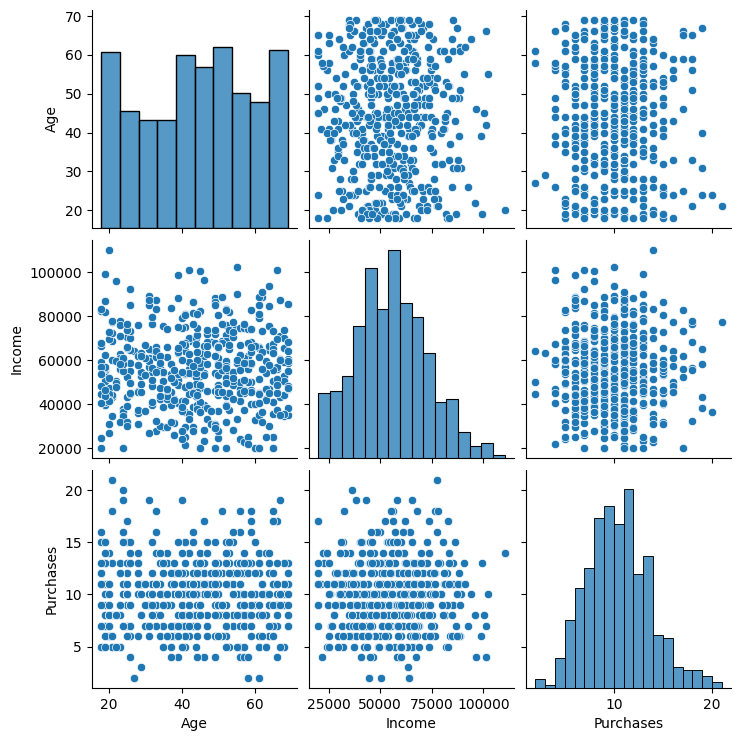

In [21]:
sns.pairplot(df[["Age", "Income", "Purchases"]])